In [1]:
import sqlite3
import re
from collections import defaultdict

DB = "/home/simonhans/coding/dada_science/library_recommender/library.db"
con = sqlite3.connect(DB)
rows = con.execute("""
    SELECT b.genre, ur.times_read, ur.reread_demands, ur.false_starts, ur.avg_rating
    FROM user_ratings ur JOIN books b ON b.id = ur.book_id
    WHERE ur.user='heiki' AND ur.times_read > 0
""").fetchall()
con.close()

SPLIT_RE = re.compile(r";|<delimit>")  # scraper bug: some rows use a literal "<delimit>" token, not ";"


def normalize(tag):
    t = tag.strip().rstrip(".").strip()
    t = re.sub(r"\s+", " ", t)
    return t


def canon_key(tag):
    return normalize(tag).lower()


display_forms = defaultdict(lambda: defaultdict(int))
per_tag_books = defaultdict(list)

for genre_raw, reads, rereads, fs, rating in rows:
    if not genre_raw:
        continue
    seen_keys = set()
    for part in SPLIT_RE.split(genre_raw):
        part = normalize(part)
        if not part:
            continue
        key = canon_key(part)
        display_forms[key][part] += 1
        if key in seen_keys:
            continue
        seen_keys.add(key)
        per_tag_books[key].append((reads, rereads, fs, rating))

results = []
for key, books in per_tag_books.items():
    label = max(display_forms[key].items(), key=lambda kv: kv[1])[0]
    n = len(books)
    total_reads = sum(b[0] for b in books)
    total_rereads = sum(b[1] for b in books)
    fs_rate = sum(1 for b in books if b[2] > 0) / n
    ratings = [b[3] for b in books if b[3] is not None]
    avg_rating = sum(ratings) / len(ratings) if ratings else float("nan")
    reread_rate = total_rereads / total_reads if total_reads else float("nan")
    results.append((label, n, avg_rating, reread_rate, fs_rate))

results.sort(key=lambda r: -r[1])
print(f"{len(rows)} books, {len(results)} distinct normalized genre tags, "
      f"{sum(1 for r in results if r[1] >= 5)} with n>=5\n")
print(f"{'tag':40s} {'n':>3s} {'avg_rating':>10s} {'reread_rate':>11s} {'false_start_rate':>17s}")
for label, n, avg_rating, reread_rate, fs_rate in results:
    flag = " <-- n>=5" if n >= 5 else ""
    print(f"{label:40s} {n:3d} {avg_rating:10.2f} {reread_rate:11.2f} {fs_rate:17.2f}{flag}")

72 books, 27 distinct normalized genre tags, 7 with n>=5

tag                                        n avg_rating reread_rate  false_start_rate
Juvenile Fiction                          39       4.24        0.29              0.18 <-- n>=5
Picture books                             38       4.47        0.26              0.11 <-- n>=5
Fiction                                   36       4.14        0.22              0.11 <-- n>=5
Juvenile works                            29       4.39        0.27              0.14 <-- n>=5
Juvenile Literature                       26       4.45        0.19              0.15 <-- n>=5
Stories in rhyme                           9       4.86        0.22              0.22 <-- n>=5
Instructional and educational works        5       4.40        0.24              0.20 <-- n>=5
Animal fiction                             4       4.56        0.41              0.00
Readers (Publications)                     4       4.44        0.10              0.25
Creative Nonfiction

In [2]:
from collections import Counter

big5 = {"fiction", "juvenile fiction", "juvenile works", "juvenile literature", "picture books"}
overlap_counts = []
for genre_raw, *_ in rows:
    if not genre_raw:
        continue
    tags = {canon_key(t) for t in SPLIT_RE.split(genre_raw) if normalize(t)}
    overlap_counts.append(len(tags & big5))

print("how many of the 5 boilerplate tags each book carries at once:")
print(sorted(Counter(overlap_counts).items()))

how many of the 5 boilerplate tags each book carries at once:
[(0, 2), (1, 14), (2, 23), (3, 20), (4, 12)]


In [3]:
BUCKETS = [
    ("Nonfiction", {"instructional and educational works", "informational works",
                     "creative nonfiction", "biography", "biographies", "history"}),
    ("Folklore", {"folklore", "legends", "folk tales"}),
    ("Animal/nature fiction", {"animal fiction", "nature fiction"}),
    ("Rhyme/verse", {"stories in rhyme"}),
]
DEFAULT_BUCKET = "General fiction"

con = sqlite3.connect(DB)
full_rows = con.execute("""
    SELECT b.title, b.genre, ur.times_read, ur.reread_demands, ur.false_starts, ur.avg_rating
    FROM user_ratings ur JOIN books b ON b.id = ur.book_id
    WHERE ur.user='heiki' AND ur.times_read > 0
""").fetchall()
con.close()

assigned = defaultdict(list)   # bucket -> list of (reads, rereads, fs, rating)
multi_match = []               # books matching >1 bucket, to eyeball the precedence call
no_tag_at_all = []

for title, genre_raw, reads, rereads, fs, rating in full_rows:
    tags = {canon_key(t) for t in SPLIT_RE.split(genre_raw or "") if normalize(t)}
    hits = [name for name, keys in BUCKETS if tags & keys]
    if len(hits) > 1:
        multi_match.append((title, hits))
    bucket = hits[0] if hits else DEFAULT_BUCKET
    if not tags:
        no_tag_at_all.append(title)
    assigned[bucket].append((reads, rereads, fs, rating))

print(f"{len(multi_match)} books matched more than one bucket (first in BUCKETS order wins):")
for t, h in multi_match:
    print(f"  {t}: {h}")
print(f"\n{len(no_tag_at_all)} books had no genre tag at all -> fell to '{DEFAULT_BUCKET}': {no_tag_at_all}")

1 books matched more than one bucket (first in BUCKETS order wins):
  A Spider Named Itsy: ['Animal/nature fiction', 'Rhyme/verse']

1 books had no genre tag at all -> fell to 'General fiction': ['AH, MUSIC!']


In [4]:
print(f"{'bucket':24s} {'n':>3s} {'total_reads':>11s} {'avg_rating':>10s} {'reread_rate':>11s} {'false_start_rate':>17s}")
for bucket, books in sorted(assigned.items(), key=lambda kv: -len(kv[1])):
    n = len(books)
    total_reads = sum(b[0] for b in books)
    total_rereads = sum(b[1] for b in books)
    fs_rate = sum(1 for b in books if b[2] > 0) / n
    ratings = [b[3] for b in books if b[3] is not None]
    avg_rating = sum(ratings) / len(ratings) if ratings else float("nan")
    reread_rate = total_rereads / total_reads if total_reads else float("nan")
    print(f"{bucket:24s} {n:3d} {total_reads:11d} {avg_rating:10.2f} {reread_rate:11.2f} {fs_rate:17.2f}")

assert sum(len(v) for v in assigned.values()) == len(full_rows)

bucket                     n total_reads avg_rating reread_rate  false_start_rate
General fiction           41         205       4.01        0.24              0.15
Nonfiction                13          57       4.46        0.16              0.15
Rhyme/verse                8          46       4.84        0.15              0.25
Animal/nature fiction      6          35       4.58        0.40              0.00
Folklore                   4          12       4.38        0.17              0.00


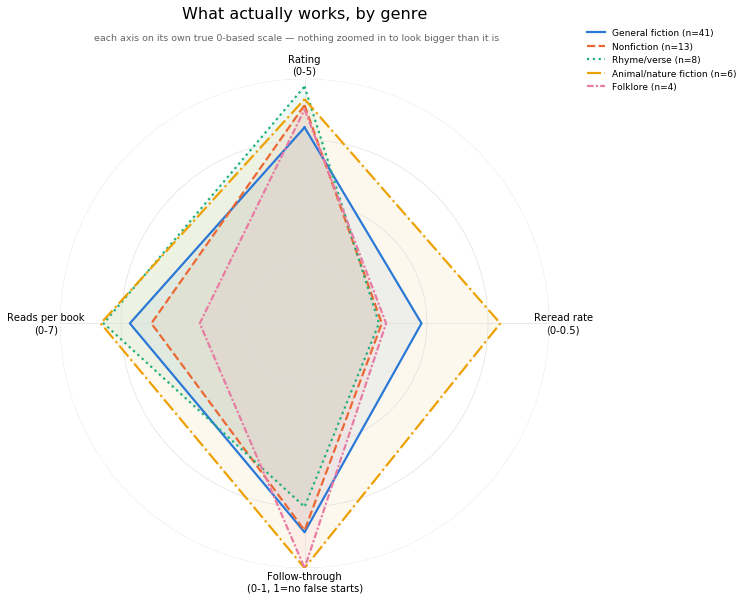

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# axes on their true scale (zero-based, not zoomed) — rating barely discriminates buckets,
# and that should visibly compress on the chart rather than get stretched to look meaningful
METRICS = [
    ("Rating\n(0-5)", "rating", 5.0),
    ("Reread rate\n(0-0.5)", "reread_rate", 0.5),
    ("Follow-through\n(0-1, 1=no false starts)", "follow_through", 1.0),
    ("Reads per book\n(0-7)", "avg_reads", 7.0),
]

bucket_stats = {}
for bucket, books in assigned.items():
    n = len(books)
    total_reads = sum(b[0] for b in books)
    total_rereads = sum(b[1] for b in books)
    fs_rate = sum(1 for b in books if b[2] > 0) / n
    ratings = [b[3] for b in books if b[3] is not None]
    bucket_stats[bucket] = dict(
        n=n,
        rating=sum(ratings) / len(ratings) if ratings else float("nan"),
        reread_rate=total_rereads / total_reads if total_reads else float("nan"),
        follow_through=1 - fs_rate,
        avg_reads=total_reads / n,
    )

order = sorted(bucket_stats, key=lambda b: -bucket_stats[b]["n"])

# palette's first 3 categorical slots are the only ones that clear the CVD all-pairs floor at
# this series count (dataviz skill, palette.md) — slots 4-5 stay in the fixed order anyway,
# but every series also gets its own linestyle so identity never depends on hue alone
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
LINESTYLES = ["-", "--", ":", "-.", (0, (3, 1, 1, 1))]

N = len(METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for bucket, color, ls in zip(order, COLORS, LINESTYLES):
    st = bucket_stats[bucket]
    vals = [st[key] / domain for _, key, domain in METRICS]
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linestyle=ls, linewidth=2.2,
             label=f"{bucket} (n={st['n']})")
    ax.fill(angles, vals, color=color, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([m[0] for m in METRICS], fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels([])
ax.spines["polar"].set_visible(False)
ax.grid(color="#dddddd", linewidth=0.6)

ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.12), frameon=False, fontsize=9)
ax.set_title("What actually works, by genre", fontsize=16, pad=36)
fig.text(0.5, 0.94, "each axis on its own true 0-based scale — nothing zoomed in to look bigger than it is",
          ha="center", fontsize=9.5, color="#666666")

fig.savefig("heiki_genre_radar.png", dpi=200, bbox_inches="tight")
plt.show()